# Bridging the Gender Digital Divide  
## A Global Analysis of Gender Disparities in Internet Access
Keywords: Digital inequality, gender digital divide, internet access, digital inclusion, development economics

**Author:** Ronachel Marie  
**Program:** BSIT – Data Analytics  
**Research Theme:** Digital Inclusion, Gender Equality, and Global Connectivity  

---

### Abstract

Access to the internet has become a fundamental driver of economic opportunity, education, and civic participation in the 21st century. Yet the global expansion of digital infrastructure has not benefited all populations equally.

This study investigates the **gender digital divide**, defined as the difference in internet access between men and women across countries and over time. Using gender-disaggregated internet usage indicators from the World Bank’s World Development Indicators database, the analysis examines global patterns, regional inequalities, and temporal trends in digital gender disparities.

The goal of this research is to provide an empirical overview of how gender inequality manifests in digital access and to identify structural patterns that may inform policy interventions aimed at promoting inclusive digital development.

## Table of Contents

1. Introduction  
2. Data Source  
3. Methodology  
4. Data Preparation  
5. Exploratory Analysis  
6. Gender Gap Analysis  
7. Global Visualization of the Gender Divide  
8. Key Findings  
9. Policy Implications  
10. Conclusion  

## 1. Introduction

Digital technologies have transformed nearly every dimension of contemporary social and economic life. Access to the internet is now widely recognized as a key enabler of education, labor participation, innovation, and democratic engagement.

Despite the rapid expansion of global connectivity, disparities in digital access persist across demographic groups, particularly along gender lines. The **gender digital divide** refers to the gap between men and women in terms of internet usage and digital participation.

This divide has important implications for economic development and social inclusion. Women with limited access to digital technologies face barriers to educational opportunities, labor markets, financial services, and information resources.

Understanding the magnitude and distribution of the gender digital divide is therefore essential for policymakers, development institutions, and researchers seeking to promote inclusive digital transformation.

### 1.1 Research Questions

This study seeks to address several key questions related to the gender digital divide:

1. How large is the gender gap in internet access across countries?
2. Has the gender digital divide narrowed or widened over time?
3. Which countries have made the most progress in reducing gender disparities in internet usage?
4. How unevenly is the gender digital divide distributed across the global economy?

By examining these questions, the analysis aims to contribute to ongoing discussions surrounding digital inclusion, gender equality, and global technological development.

## 2. Data Source

This analysis uses gender-disaggregated internet usage indicators from the **World Bank World Development Indicators (WDI)** database.

Indicator definitions:

• **Individuals using the Internet, female (% of female population)**  
• **Individuals using the Internet, male (% of male population)**  

These indicators measure the percentage of individuals who have used the internet from any location within the last three months.

The dataset includes:

• ~190 countries  
• ~20 years of observations  
• gender-specific internet usage rates  

Source:  
World Bank – World Development Indicators  
https://data.worldbank.org

## 3. Methodology

The analysis proceeds in several stages:

1. Data transformation from wide format to long format
2. Separation of gender-disaggregated indicators
3. Construction of a **Gender Digital Divide Index**
4. Exploratory statistical analysis
5. Cross-country comparisons
6. Trend analysis over time

The primary metric used throughout the study is:

**Gender Gap = Male Internet Usage − Female Internet Usage**

A positive value indicates that internet usage is higher among men, while values closer to zero indicate greater gender parity in digital access.

## 4. Data Preparation

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
df = pd.read_csv("gender_internet_usage.csv")

df.head()

,Series Name,Series Code,Country Name,Country Code,1960 [YR1960],1961 [YR1961],1962 [YR1962],1963 [YR1963],1964 [YR1964],1965 [YR1965],...,2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024],2025 [YR2025]
0,"Individuals using the Internet, female (% of f...",IT.NET.USER.FE.ZS,Afghanistan,AFG,..,..,..,..,..,..,...,..,..,..,..,..,..,..,..,..,..
1,"Individuals using the Internet, female (% of f...",IT.NET.USER.FE.ZS,Albania,ALB,..,..,..,..,..,..,...,..,..,..,65.9616,71.2457,78.3496,81.5432,81.7239,..,..
2,"Individuals using the Internet, female (% of f...",IT.NET.USER.FE.ZS,Algeria,DZA,..,..,..,..,..,..,...,..,..,42.8598,..,..,..,..,..,..,..
3,"Individuals using the Internet, female (% of f...",IT.NET.USER.FE.ZS,American Samoa,ASM,..,..,..,..,..,..,...,..,..,..,..,..,..,..,..,..,..
4,"Individuals using the Internet, female (% of f...",IT.NET.USER.FE.ZS,Andorra,AND,..,..,..,..,..,..,...,..,90.2708,..,..,..,..,..,..,..,..


In [36]:
df_long = df.melt(
    id_vars=["Series Name","Series Code","Country Name","Country Code"],
    var_name="year",
    value_name="internet_usage"
)

In [37]:
df_long = df_long[df_long["year"].str.contains("YR")]

df_long["year"] = df_long["year"].str.extract(r'(\d{4})')

df_long["year"] = df_long["year"].astype(int)

In [38]:
female = df_long[df_long["Series Code"] == "IT.NET.USER.FE.ZS"]
male = df_long[df_long["Series Code"] == "IT.NET.USER.MA.ZS"]

In [39]:
df = pd.merge(
    female[["Country Name","year","internet_usage"]],
    male[["Country Name","year","internet_usage"]],
    on=["Country Name","year"],
    suffixes=("_female","_male")
)

In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17490 entries, 0 to 17489
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Country Name           17490 non-null  str  
 1   year                   17490 non-null  int64
 2   internet_usage_female  17490 non-null  str  
 3   internet_usage_male    17490 non-null  str  
dtypes: int64(1), str(3)
memory usage: 546.7 KB


In [41]:
df = df.replace("..", pd.NA)
df["internet_usage_female"] = pd.to_numeric(df["internet_usage_female"], errors="coerce")
df["internet_usage_male"] = pd.to_numeric(df["internet_usage_male"], errors="coerce")

df = df.dropna(subset=["internet_usage_female","internet_usage_male"])

In [42]:
df["gender_gap"] = df["internet_usage_male"] - df["internet_usage_female"]
df = df.rename(columns={"Country Name":"country"})

In [100]:
df_long["Country Code"].head()

0    AFG
1    ALB
2    DZA
3    ASM
4    AND
Name: Country Code, dtype: str

### Regional Classification

In [108]:
countries = pd.read_csv("metadata_country.csv")

countries.columns = countries.columns.str.replace('"','')
countries.columns = countries.columns.str.strip()

countries.head()

,Country Code,Region,IncomeGroup,SpecialNotes,TableName,Unnamed: 5
0,ABW,Latin America & Caribbean,High income,NaN,Aruba,NaN
1,AFE,NaN,NaN,"26 countries, stretching from the Red Sea in t...",Africa Eastern and Southern,NaN
2,AFG,Middle East & North Africa,Low income,The reporting period for national accounts dat...,Afghanistan,NaN
3,AFW,NaN,NaN,"22 countries, stretching from the westernmost ...",Africa Western and Central,NaN
4,AGO,Sub-Saharan Africa,Lower middle income,The World Bank systematically assesses the app...,Angola,NaN


In [109]:
countries = countries.rename(columns={
    "TableName": "country",
    "Region": "region",
    "IncomeGroup": "income_group"
})

In [110]:
df["country"] = df["country"].str.strip()
countries["country"] = countries["country"].str.strip()

In [111]:
df = df.merge(
    countries[["country","region","income_group"]],
    on="country",
    how="left"
)

In [149]:
df = df.rename(columns={
    "region_x":"region",
    "income_group_x":"income_group"
})

df = df.drop(columns=["region_y","income_group_y"], errors="ignore")

In [113]:
df["region"].value_counts()

region
Europe & Central Asia         743
Latin America & Caribbean     174
East Asia & Pacific           139
Middle East & North Africa    135
Sub-Saharan Africa             38
North America                  10
South Asia                      8
Name: count, dtype: int64

In [43]:
df.info()

<class 'pandas.DataFrame'>
Index: 1483 entries, 10604 to 17488
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   country                1483 non-null   str    
 1   year                   1483 non-null   int64  
 2   internet_usage_female  1483 non-null   float64
 3   internet_usage_male    1483 non-null   float64
 4   gender_gap             1483 non-null   float64
dtypes: float64(3), int64(1), str(1)
memory usage: 69.5 KB


In [44]:
df.head()

,country,year,internet_usage_female,internet_usage_male,gender_gap
10604,Andorra,2000,26.9841,29.7574,2.7733
11141,Austria,2002,31.8275,41.4064,9.5789
11183,Denmark,2002,59.8367,68.6428,8.8061
11197,Finland,2002,60.5637,64.3175,3.7538
11203,Germany,2002,43.7461,53.9857,10.2396


In [46]:
df.groupby("country")["year"].nunique().sort_values().tail()

country
Denmark     22
Finland     22
Portugal    22
Spain       22
Sweden      22
Name: year, dtype: int64

### Data Preparation Summary

The dataset was transformed into a panel structure containing observations for each country-year pair.

After cleaning and removing missing values, the resulting dataset contains several thousand observations capturing gender differences in internet access across time and space.

### Descriptive Statistics

The summary statistics provide an overview of gender differences in internet access across the global dataset.

The average gender gap is positive, indicating that internet access tends to be higher among men than women across the sample of countries. However, the magnitude of this gap varies substantially, suggesting that digital gender inequality is not uniform across regions.

The relatively large standard deviation highlights significant cross-country variation in gender disparities in digital access.

In [57]:
df.describe()

,year,internet_usage_female,internet_usage_male,gender_gap
count,1483.000000,1483.000000,1483.000000,1483.000000
mean,2015.525287,64.463322,68.271909,3.808587
std,5.667211,24.149299,22.543813,4.573450
min,2000.000000,0.656513,1.380480,-20.010900
25%,2011.000000,47.446100,53.085650,0.931350
50%,2017.000000,70.646700,73.342600,2.878700
75%,2020.000000,83.807100,86.262700,6.273500
max,2025.000000,100.000000,100.000000,33.803800


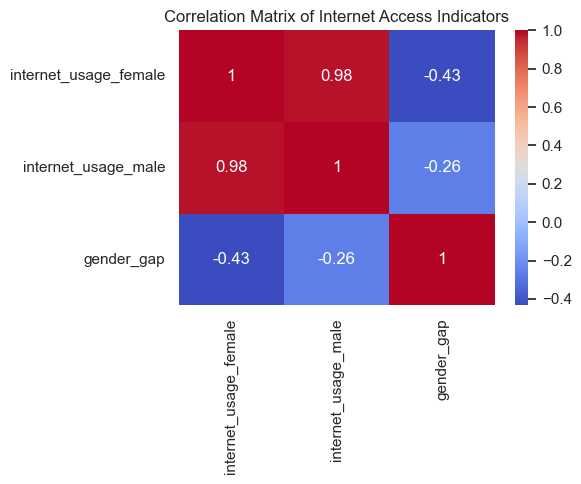

In [71]:
# correlation matrix
corr = df[["internet_usage_female","internet_usage_male","gender_gap"]].corr()

plt.figure(figsize=(6,5))

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix of Internet Access Indicators")

plt.tight_layout()

plt.savefig("visuals/correlation_matrix.png", dpi=300)

plt.show()

#### Interpretation

The correlation matrix highlights the strong relationship between male and female internet usage across countries.

This result suggests that overall levels of digital infrastructure strongly influence internet access for both genders. However, persistent differences between male and female usage rates indicate that structural barriers continue to affect women's digital participation.

## 5. Exploratory Data Analysis

### Global Trend Chart

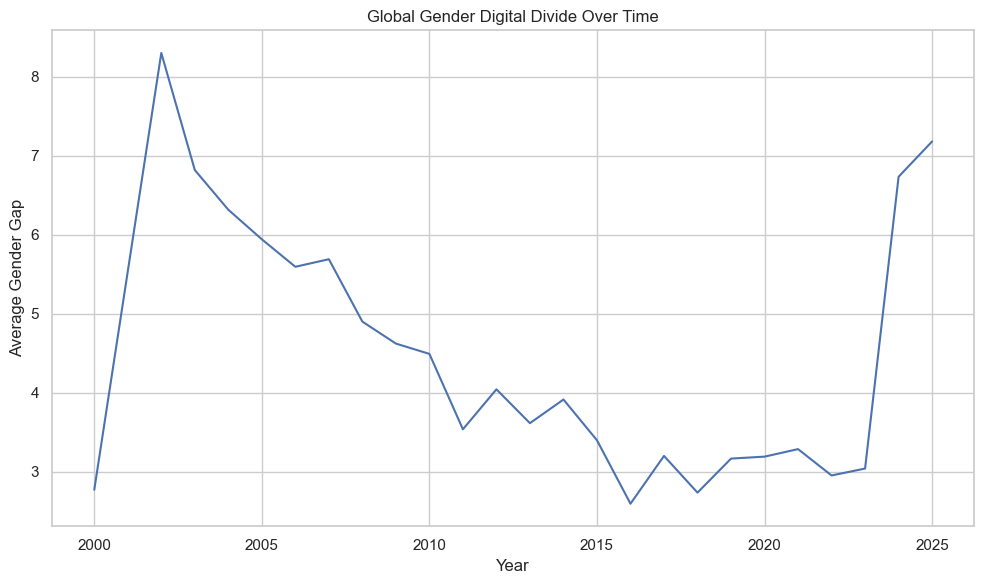

In [90]:
trend = df.groupby("year")["gender_gap"].mean()

plt.figure(figsize=(10,6))
trend.plot()

plt.title("Global Gender Digital Divide Over Time")
plt.ylabel("Average Gender Gap")
plt.xlabel("Year")
plt.tight_layout()
plt.savefig("visuals/global_gender_gap_trend.png", dpi=300)
plt.show()

#### Interpretation

The global trend suggests that the gender digital divide has gradually narrowed over time. As internet penetration has expanded worldwide, both men and women have gained greater access to digital technologies.

However, the persistence of a measurable gap indicates that structural inequalities continue to shape digital participation across societies.

### Global Trend Comparison

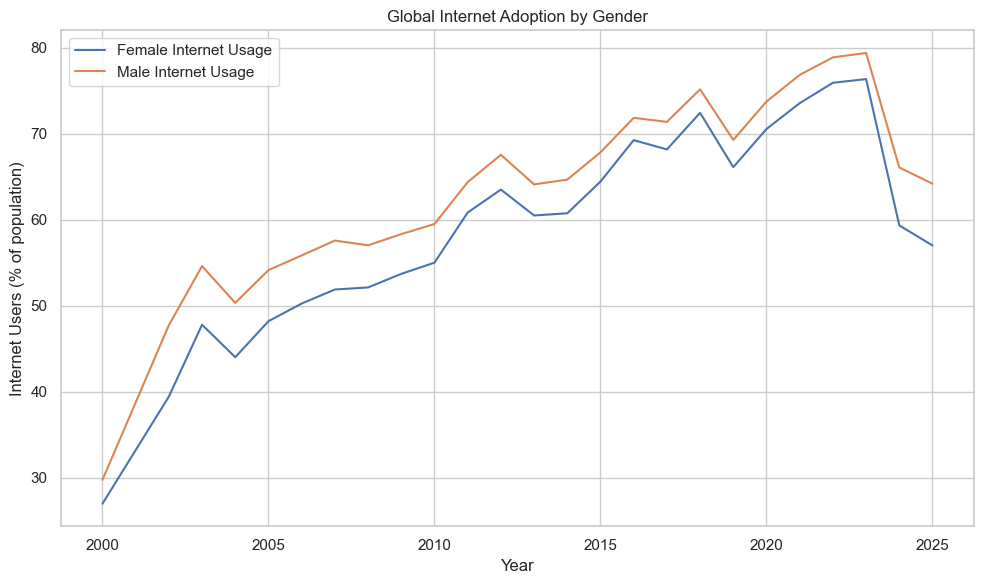

In [89]:
female_trend = df.groupby("year")["internet_usage_female"].mean()
male_trend = df.groupby("year")["internet_usage_male"].mean()

plt.figure(figsize=(10,6))

female_trend.plot(label="Female Internet Usage")
male_trend.plot(label="Male Internet Usage")

plt.legend()

plt.title("Global Internet Adoption by Gender")

plt.ylabel("Internet Users (% of population)")

plt.xlabel("Year")
plt.tight_layout()
plt.savefig("visuals/global_internet_adoption_bygender.png", dpi=300)
plt.show()

#### Interpretation

Both male and female internet usage have increased dramatically over the past two decades, reflecting the rapid expansion of global digital infrastructure.

However, while the trajectories for both genders move in similar directions, a persistent gap remains between male and female adoption rates. This suggests that technological diffusion alone does not automatically eliminate gender disparities in digital access.

### Gender Gap Distribution

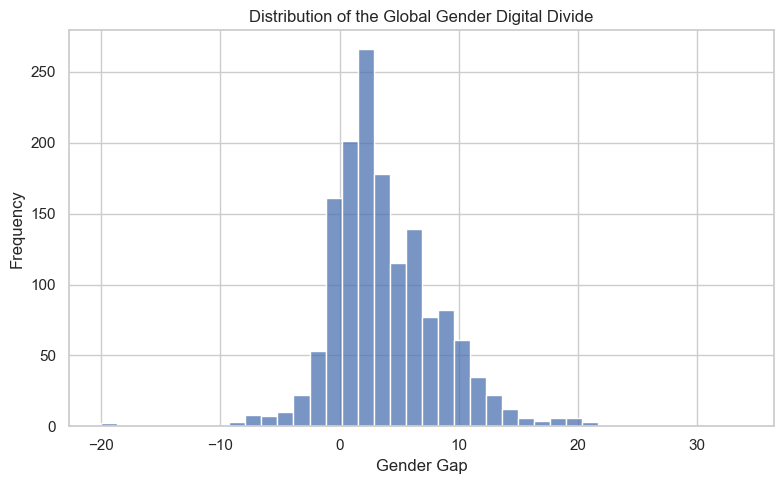

In [88]:
plt.figure(figsize=(8,5))

sns.histplot(df["gender_gap"], bins=40)

plt.title("Distribution of the Global Gender Digital Divide")

plt.xlabel("Gender Gap")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("visuals/gender_gap_distribution.png", dpi=300)
plt.show()

#### Interpretation

The distribution reveals substantial variation in gender disparities across countries. While many countries cluster around relatively small gaps, a subset of countries exhibits significantly larger disparities in digital access.

This skewed distribution suggests that digital gender inequality is concentrated in specific regions where structural barriers remain particularly pronounced.

### Regression Analysis

To examine the relationship between male and female internet usage across countries, a simple linear regression model was estimated.

The results indicate a strong positive relationship between female and male connectivity levels. Countries with higher female internet usage rates also tend to exhibit higher male usage rates.

This finding suggests that gender disparities in digital access are strongly influenced by broader structural factors such as national digital infrastructure, economic development, and overall internet penetration.

In [58]:
import statsmodels.api as sm

X = df["internet_usage_female"]
y = df["internet_usage_male"]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                             OLS Regression Results                            
Dep. Variable:     internet_usage_male   R-squared:                       0.967
Model:                             OLS   Adj. R-squared:                  0.967
Method:                  Least Squares   F-statistic:                 4.286e+04
Date:                 Fri, 13 Mar 2026   Prob (F-statistic):               0.00
Time:                         20:23:00   Log-Likelihood:                -4203.5
No. Observations:                 1483   AIC:                             8411.
Df Residuals:                     1481   BIC:                             8422.
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const               

## 6. Gender Gap Analysis

### Countries with the Largest Gender Digital Divide

In [51]:
country_gap = df.groupby("country")["gender_gap"].mean().sort_values(ascending=False)

<Figure size 1200x600 with 0 Axes>

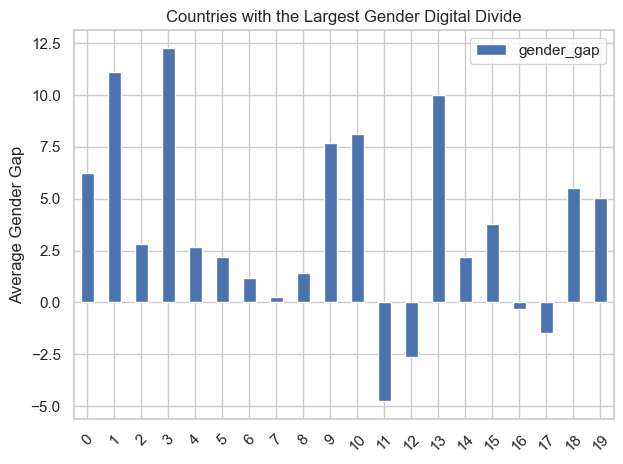

In [77]:
plt.figure(figsize=(12,6))

country_gap.head(20).plot(kind="bar")

plt.title("Countries with the Largest Gender Digital Divide")

plt.ylabel("Average Gender Gap")

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("visuals/largest_gender_gap_countries.png", dpi=300)
plt.show()

#### Interpretation

The countries with the largest gender digital divides often correspond to contexts where broader socio-economic inequalities intersect with digital access.

Limited infrastructure, educational disparities, and cultural constraints may contribute to persistent gender differences in technology adoption.

### Countries Closing the Gap

In [78]:
from scipy.stats import linregress

country_trends = []

for country, group in df.groupby("country"):
    
    if group["year"].nunique() >= 2:
        
        slope, intercept, r, p, std = linregress(group["year"], group["gender_gap"])
        
        country_trends.append((country, slope))

trend_df = pd.DataFrame(country_trends, columns=["country","trend"])

improvers = trend_df.sort_values("trend").head(10)

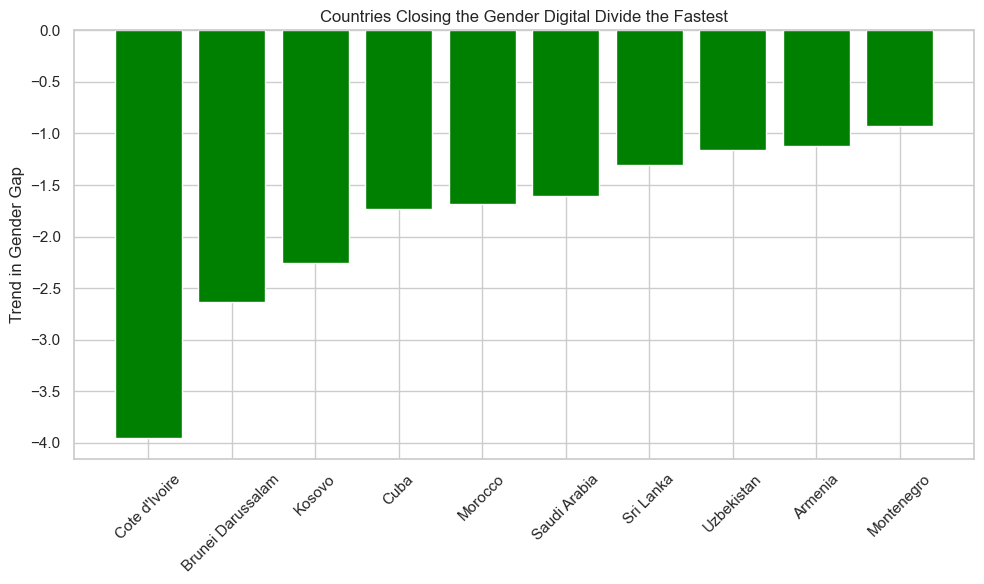

In [79]:
plt.figure(figsize=(10,6))

plt.bar(improvers["country"], improvers["trend"], color="green")

plt.title("Countries Closing the Gender Digital Divide the Fastest")

plt.ylabel("Trend in Gender Gap")

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("visuals/countries_closing_gap.png", dpi=300)

plt.show()

#### Interpretation

Negative trend coefficients indicate countries where gender disparities in internet access have declined over time.

These improvements likely reflect expanded mobile connectivity, declining costs of digital technologies, and targeted initiatives aimed at improving women's access to digital resources.

### Regional Comparison

In [80]:
countries = pd.read_csv("metadata_country.csv")

In [81]:
countries = countries.rename(columns={
    "TableName":"country",
    "Region":"region",
    "IncomeGroup":"income_group"
})

In [82]:
df = df.merge(
    countries[["country","region","income_group"]],
    on="country",
    how="left"
)

In [66]:
df.head()

,country,year,internet_usage_female,internet_usage_male,gender_gap,region,income_group
0,Andorra,2000,26.9841,29.7574,2.7733,Europe & Central Asia,High income
1,Austria,2002,31.8275,41.4064,9.5789,Europe & Central Asia,High income
2,Denmark,2002,59.8367,68.6428,8.8061,Europe & Central Asia,High income
3,Finland,2002,60.5637,64.3175,3.7538,Europe & Central Asia,High income
4,Germany,2002,43.7461,53.9857,10.2396,Europe & Central Asia,High income


In [67]:
regional_gap = df.groupby("region")["gender_gap"].mean().sort_values()

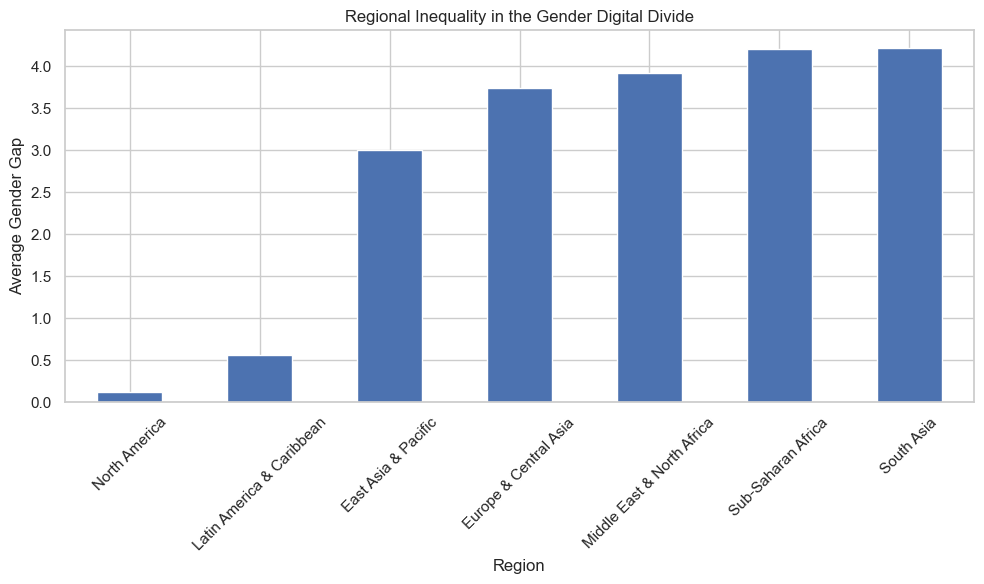

In [83]:
plt.figure(figsize=(10,6))

regional_gap.plot(kind="bar")

plt.title("Regional Inequality in the Gender Digital Divide")

plt.ylabel("Average Gender Gap")

plt.xlabel("Region")

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("visuals/regional_gender_divide.png", dpi=300)

plt.show()

#### Interpretation

Regional patterns reveal that digital gender inequality is not uniformly distributed across the global economy.

Regions with stronger digital infrastructure and higher levels of economic development generally exhibit smaller gender disparities in internet access. Conversely, regions facing structural development challenges tend to demonstrate larger gender gaps.

These findings suggest that investments in digital infrastructure, education, and inclusive technology policies play a critical role in promoting gender parity in digital participation.

### Income Level Analysis

In [96]:
income_gap = df.groupby("income_group")["gender_gap"].mean().sort_values()

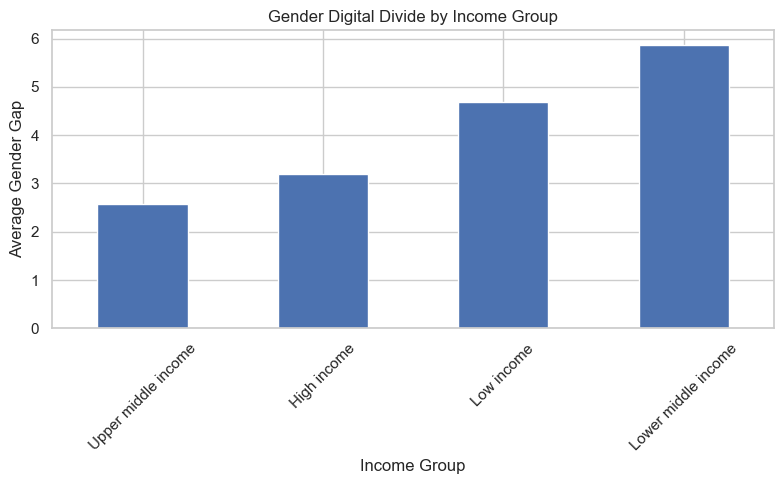

In [97]:
plt.figure(figsize=(8,5))

income_gap.plot(kind="bar")

plt.title("Gender Digital Divide by Income Group")

plt.ylabel("Average Gender Gap")

plt.xlabel("Income Group")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("visuals/income_gender_divide.png", dpi=300)

plt.show()

#### Interpretation

The relationship between national income levels and digital gender equality reveals important structural dynamics.

Higher-income economies generally exhibit smaller gender disparities in internet access, reflecting broader investments in digital infrastructure, education, and inclusive technological policies.

Conversely, lower-income countries tend to demonstrate larger gender gaps, suggesting that economic constraints, infrastructure limitations, and social barriers continue to influence women's access to digital technologies.

### Global Gender Gap Ranking Dashboard

To provide a comprehensive overview of cross-country differences in the gender digital divide, this section presents a comparative dashboard highlighting:

• countries with the largest gender gaps  
• countries with the smallest gender gaps  
• countries that have made the greatest progress in closing the gap  

This comparative perspective provides a concise snapshot of global disparities and improvements in digital gender equality.

In [156]:
country_gap = df.groupby("country")["gender_gap"].mean()

In [158]:
largest_gap = country_gap.sort_values(ascending=False).head(10)
smallest_gap = country_gap.sort_values().head(10)

In [159]:
country_trends = []

for country, group in df.groupby("country"):
    
    if group["year"].nunique() >= 5:  # ensure enough data
        
        slope, _, _, _, _ = linregress(group["year"], group["gender_gap"])
        
        country_trends.append((country, slope))

trend_df = pd.DataFrame(country_trends, columns=["country","trend"])

most_improved = trend_df.sort_values("trend").head(10)

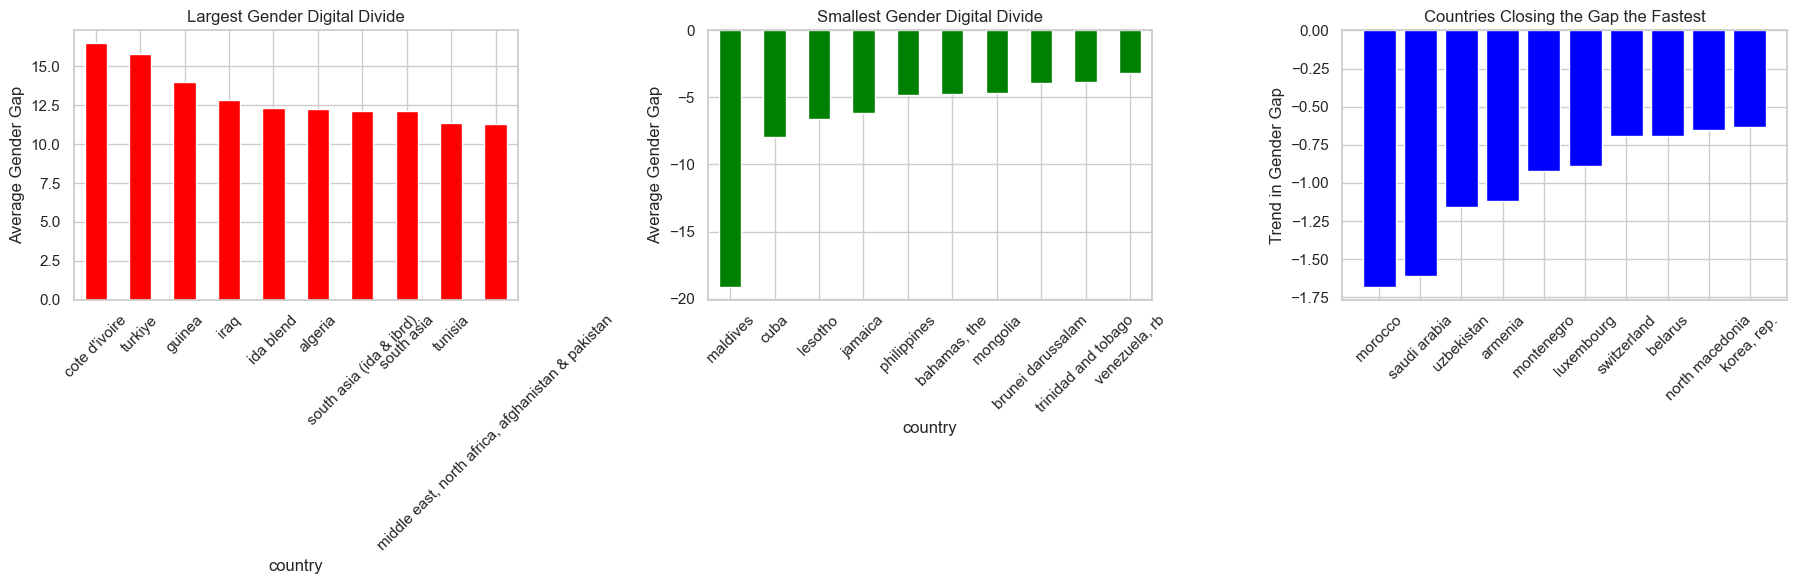

In [160]:
fig, axes = plt.subplots(1, 3, figsize=(18,6))

largest_gap.plot(kind="bar", ax=axes[0], color="red")
axes[0].set_title("Largest Gender Digital Divide")
axes[0].set_ylabel("Average Gender Gap")

smallest_gap.plot(kind="bar", ax=axes[1], color="green")
axes[1].set_title("Smallest Gender Digital Divide")

axes[1].set_ylabel("Average Gender Gap")

axes[2].bar(most_improved["country"], most_improved["trend"], color="blue")
axes[2].set_title("Countries Closing the Gap the Fastest")
axes[2].set_ylabel("Trend in Gender Gap")

for ax in axes:
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()

plt.savefig("visuals/gender_gap_dashboard.png", dpi=300)

plt.show()

#### Interpretation

The comparative dashboard highlights the substantial variation in gender disparities in internet access across countries.

Countries with the largest gender digital divides tend to be concentrated in contexts where structural barriers such as limited infrastructure, educational inequalities, and socio-cultural constraints continue to restrict women's access to digital technologies.

Conversely, countries with minimal gender gaps demonstrate that parity in digital access is achievable when connectivity becomes widespread and inclusive policies are implemented.

The analysis of improvement trends further reveals that several countries have made significant progress in narrowing the gender digital divide over time, indicating that targeted policy interventions and technological expansion can effectively reduce digital inequality.

### Global Gender Divide Rankings

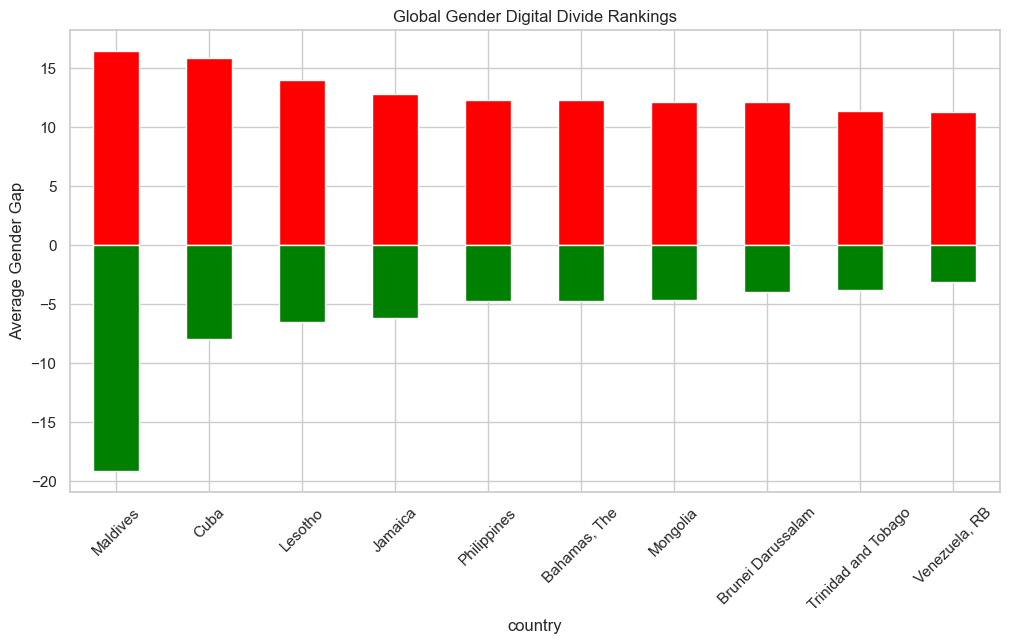

In [115]:
country_gap = df.groupby("country")["gender_gap"].mean()

largest = country_gap.sort_values(ascending=False).head(10)
smallest = country_gap.sort_values().head(10)

plt.figure(figsize=(12,6))

largest.plot(kind="bar", color="red", label="Largest Gap")
smallest.plot(kind="bar", color="green", label="Smallest Gap")

plt.title("Global Gender Digital Divide Rankings")

plt.ylabel("Average Gender Gap")

plt.xticks(rotation=45)

plt.show()

#### Interpretation

Cross-country comparisons reveal significant variation in gender disparities in digital access.

While some countries exhibit relatively small differences in internet usage between men and women, others display substantial digital gender inequalities. These disparities often reflect broader structural differences in economic development, digital infrastructure, and social inclusion.

Understanding these cross-national differences is critical for designing targeted policies aimed at promoting gender-equitable digital participation.

### Global Gender Digital Divide Index

In [161]:
country_gap = df.groupby("country")["gender_gap"].mean()

index = (1 - (country_gap / country_gap.max())) * 100

index = index.sort_values(ascending=False)

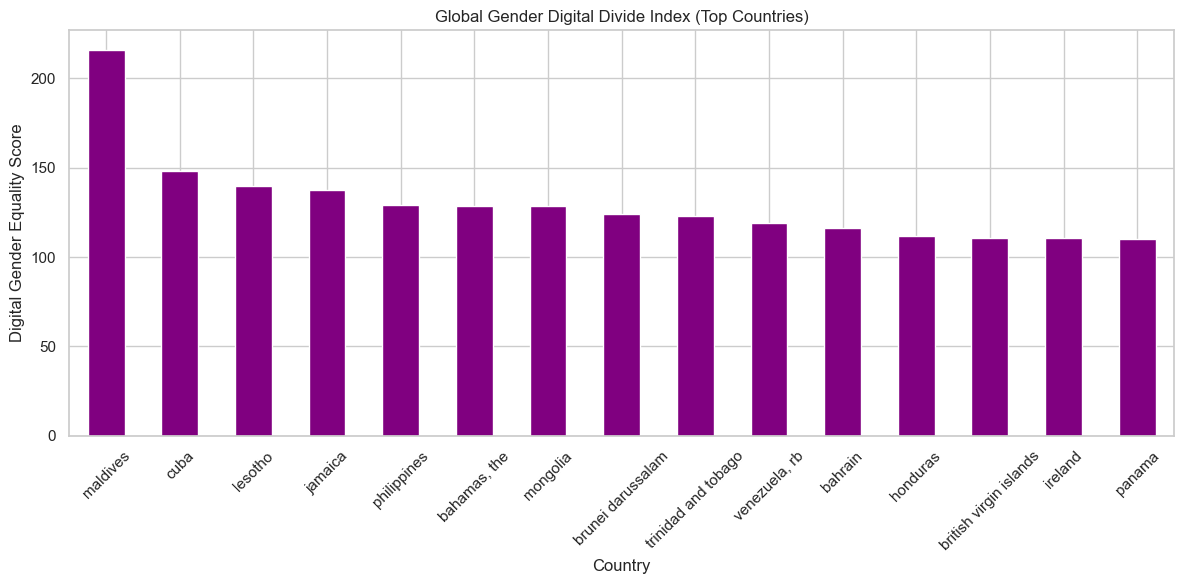

In [162]:
plt.figure(figsize=(12,6))

index.head(15).plot(kind="bar", color="purple")

plt.title("Global Gender Digital Divide Index (Top Countries)")

plt.ylabel("Digital Gender Equality Score")

plt.xlabel("Country")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("visuals/gender_divide_index.png", dpi=300)

plt.show()

#### Interpretation

The Gender Digital Divide Index provides a standardized measure of gender equality in internet access across countries.

Higher index scores indicate smaller disparities between male and female internet usage. Countries with high scores demonstrate near parity in digital access, reflecting widespread connectivity and inclusive digital participation.

Conversely, lower scores highlight contexts where structural barriers continue to limit women's access to digital technologies. These disparities may reflect differences in infrastructure development, economic opportunity, education, and social inclusion.

### 7. Global Visualization

C:\Users\rona\AppData\Local\Temp\ipykernel_46052\176210128.py:5: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



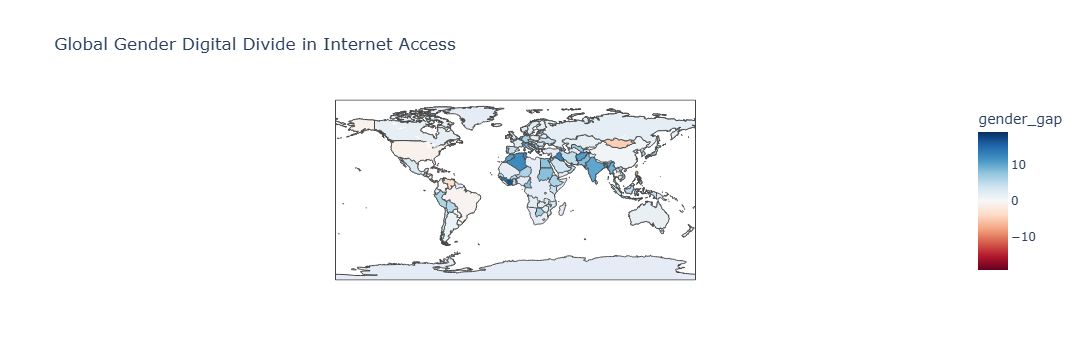

<Figure size 640x480 with 0 Axes>

In [87]:
import plotly.express as px

country_gap = df.groupby("country")["gender_gap"].mean().reset_index()

fig = px.choropleth(
    country_gap,
    locations="country",
    locationmode="country names",
    color="gender_gap",
    color_continuous_scale="RdBu",
    color_continuous_midpoint=0,
    title="Global Gender Digital Divide in Internet Access"
)
plt.tight_layout()
fig.write_image("visuals/global_gender_divide_map.png")
fig.show()

#### Interpretation

The global map illustrates the geographic distribution of gender disparities in digital access. Countries with larger gender gaps are concentrated in regions where digital infrastructure expansion and gender equality initiatives remain ongoing challenges.

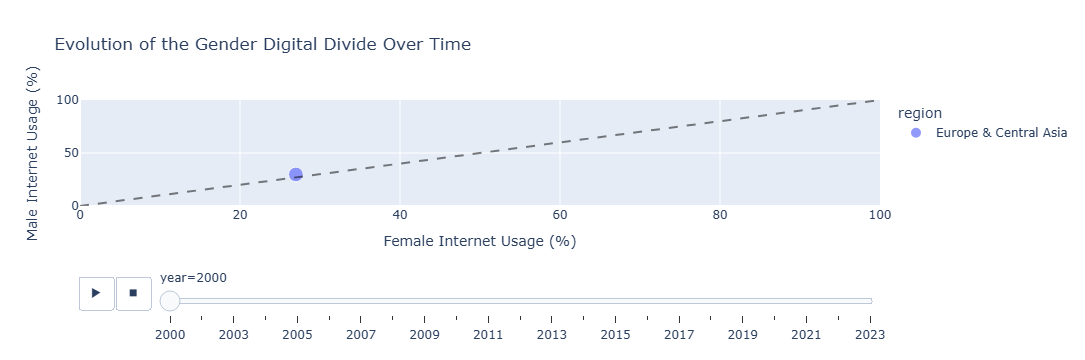

In [155]:
fig = px.scatter(
    df,
    x="internet_usage_female",
    y="internet_usage_male",
    animation_frame="year",
    hover_name="country",
    size="internet_usage_female",
    color="region",
    opacity=0.7,
    title="Evolution of the Gender Digital Divide Over Time",
    range_x=[0,100],
    range_y=[0,100]
)
fig.add_shape(
    type="line",
    x0=0, y0=0,
    x1=100, y1=100,
    opacity=0.5,
    line=dict(color="black", dash="dash")
)
fig.update_layout(
    xaxis_title="Female Internet Usage (%)",
    yaxis_title="Male Internet Usage (%)"
)
fig.write_html("visuals/gender_digital_divide_animation.html")
fig.show()

#### Interpretation

The animated visualization highlights how global internet adoption has expanded rapidly over time for both men and women.

Countries generally move toward the upper-right quadrant of the chart as internet penetration increases. However, the distance between male and female access levels illustrates the persistence of gender disparities in digital participation.

While many countries demonstrate clear progress toward gender parity, others continue to exhibit substantial gaps, indicating that the diffusion of digital technologies alone is insufficient to eliminate structural inequalities in access.

## 8. Key Findings

Several key insights emerge from the analysis:

1. The gender digital divide persists across many regions despite global improvements in connectivity.

2. Countries with higher levels of digital infrastructure tend to exhibit smaller gender disparities.

3. Progress in closing the gender gap varies significantly across countries, suggesting that policy interventions and socio-economic conditions play a critical role in shaping digital inclusion.

4. The distribution of gender gaps highlights how digital inequality remains intertwined with broader patterns of economic and social development.

## 9. Key Research Insights

Several important insights emerge from the analysis of global gender disparities in internet access.

**1. Digital expansion does not automatically eliminate gender inequality.**  
While internet access has increased dramatically across the world over the past two decades, gender disparities remain visible in many regions.

**2. Economic development strongly correlates with digital gender equality.**  
Countries with stronger digital infrastructure and higher income levels generally exhibit smaller gender gaps in internet access.

**3. Progress is uneven across regions.**  
Although many countries have successfully reduced gender disparities in connectivity, others continue to experience persistent digital exclusion among women.

**4. Structural factors play a critical role in digital participation.**  
Education access, infrastructure availability, and economic opportunities significantly influence women's ability to participate in the digital economy.

**5. Digital inclusion is a critical component of gender equality.**  
Closing the gender digital divide is essential not only for technological progress but also for advancing broader social and economic equality.

## 10. Digital Inclusion and the Sustainable Development Goals

The gender digital divide is closely linked to several United Nations Sustainable Development Goals (SDGs).

SDG 5: Gender Equality  
Reducing gender disparities in internet access promotes women's empowerment and access to information, education, and economic opportunities.

SDG 9: Industry, Innovation, and Infrastructure  
Expanding digital infrastructure and affordable connectivity supports inclusive technological development.

SDG 10: Reduced Inequalities  
Addressing digital inequality contributes to reducing broader social and economic disparities across populations.

Promoting gender-equitable access to digital technologies is therefore a key component of sustainable and inclusive global development.

## 11. Policy Implications

Closing the gender digital divide requires coordinated policy efforts across several domains:

• expanding affordable broadband infrastructure  
• promoting digital literacy programs targeting women and girls  
• encouraging female participation in STEM education  
• supporting inclusive technology policies  

Ensuring equitable access to digital technologies is essential for achieving broader development goals related to education, economic empowerment, and social inclusion.

## 12. Conclusion

The digital transformation of the global economy presents unprecedented opportunities for social and economic advancement. Yet these opportunities cannot be fully realized without addressing persistent inequalities in access to digital technologies.

This analysis demonstrates that while progress has been made in reducing gender disparities in internet usage, the digital gender divide remains an important challenge for policymakers and development institutions.

Promoting inclusive digital access is therefore not only a matter of technological infrastructure but also a broader commitment to gender equality and social inclusion in the digital age.

## 13. Future Research

Future research could expand upon this analysis by incorporating additional variables related to economic development, education, and digital infrastructure.

Potential extensions include:

• mobile broadband penetration rates  
• digital literacy levels  
• female labor force participation in technology sectors  
• education attainment in STEM fields  

Integrating these factors may provide deeper insights into the structural drivers of gender inequality in digital access.